# Precipitation balance

How well-watered — without being drought-stricken *or* deluged — a place is, per 0.5° grid cell. Uses NASA POWER climatology (1991–2020, `PRECTOTCORR`) at monthly resolution, scored against a user-tunable comfort band around a moderate monthly rainfall total. Ocean cells are masked via `is_land` from `grid.nc`.

"Balance" here means each individual month sits near a moderate rainfall band. A place that gets ~1000 mm/year spread evenly scores high, while a monsoon region that hits the same annual total via 4 soaking months and 8 dry ones scores low — that per-month penalty is the whole point.

The pipeline is two-stage, mirroring `14_temperature_pleasantness.ipynb`:

1. **Stage A (expensive, run once):** fetch monthly `PRECTOTCORR` (mm/day averaged per month), convert to monthly totals in mm, interpolate onto the atlas grid, cache to `processed/_precipitation_monthly.nc`.
2. **Stage B (cheap, rerun any time):** collapse the 12 monthly layers into an annual balance score using two knobs (`ideal_monthly_mm`, `tolerance_mm`). This is what `90_scoring.ipynb` consumes.

Changing preferences after the fact does not re-hit the API or re-interpolate — just call `common.compute_precipitation_balance(source, ideal_monthly_mm, tolerance_mm)`.

**Trade-off note.** DATASETS.md flags CHIRPS as "better for rainy-day counting" because it's daily at ~5 km. We stick with NASA POWER for consistency with `13_sun_hours` / `14_temperature_pleasantness` — no new API key, no new fetch loop, and the monthly-total triangular scoring already captures the drought-vs-deluge signal we care about. A future switch to CHIRPS would only affect Stage A.

In [1]:
import json

import numpy as np
import pandas as pd

from common import (
    RAW_DIR,
    PROCESSED_DIR,
    compute_precipitation_balance,
    load_grid,
    plot_map,
    save_variable,
)

VARIABLE = 'precipitation_balance'
variable_raw = RAW_DIR / VARIABLE
variable_raw.mkdir(parents=True, exist_ok=True)
intermediate = PROCESSED_DIR / '_precipitation_monthly.nc'

## 1. Fetch raw data

NASA POWER's climatology *regional* endpoint returns monthly + annual means on a 0.5° lat × 0.625° lon grid. The endpoint caps request area at ~10° × 10°, so we tile the globe into 648 tiles and cache each response as JSON. Same pattern as `13_sun_hours.ipynb` / `14_temperature_pleasantness.ipynb`, requesting `PRECTOTCORR` (bias-corrected total precipitation, mm/day averaged per month).

First run: ~15–25 min (sequential requests). Re-runs: instant (cached).

In [2]:
from common import download_nasa_power_dataset
download_nasa_power_dataset(variable_raw, "PRECTOTCORR")

POWER tiles: 100%|██████████| 648/648 [00:00<00:00, 118945.69it/s]

648 tiles cached in /Users/lutz/Documents/alfatraining/projects/data-science-notebooks/data/world-livable-atlas/raw/precipitation_balance


## 2. Clean & assemble monthly climatology

Each tile JSON is a GeoJSON FeatureCollection. Every feature is a grid point with `geometry.coordinates = [lon, lat]` and `properties.parameter.PRECTOTCORR.{JAN..DEC, ANN}` in **mm/day** (climatological monthly averages). NASA POWER uses `-999` as its fill value — skip those.

We convert to **mm/month** by multiplying by the number of days in each month. Using the standard non-leap-year calendar is fine — the climatology is a long-term mean, and the ~0.25-day leap-year adjustment is well inside the precision of the triangular scoring band applied downstream.

In [3]:
MONTHS = ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN',
          'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC']
DAYS_IN_MONTH = np.array([31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31])

records = []
for tile_path in sorted(variable_raw.glob('tile_*_PRECTOTCORR.json')):
    doc = json.loads(tile_path.read_text())
    for feature in doc['features']:
        lon, lat = feature['geometry']['coordinates'][:2]  # ignore elevation
        p = feature['properties']['parameter']['PRECTOTCORR']
        for m_idx, m in enumerate(MONTHS, start=1):
            pv = p.get(m)
            if pv is None or pv < -900:
                continue
            # mm/day → mm/month
            records.append((lat, lon, m_idx, pv * DAYS_IN_MONTH[m_idx - 1]))

df = pd.DataFrame(records, columns=['lat', 'lon', 'month', 'precip_mm']) \
    .drop_duplicates(['lat', 'lon', 'month'])
df

,lat,lon,month,precip_mm
0,0.5,0.625,1,102.61
1,0.5,0.625,2,85.68
2,0.5,0.625,3,125.55
3,0.5,0.625,4,152.10
4,0.5,0.625,5,134.85
...,...,...,...,...
2759419,-80.5,-170.625,8,10.54
2759420,-80.5,-170.625,9,8.40
2759421,-80.5,-170.625,10,9.61
2759422,-80.5,-170.625,11,6.00


## 3. Interpolate onto the grid

Pivot to an xarray `(month, lat, lon)` cube, bilinear-interp onto the 0.5° atlas grid (same method as `13_sun_hours.ipynb`), mask ocean, and cache to `processed/_precipitation_monthly.nc`. The underscore prefix signals this file is **not** a scoring layer — it's the frozen precipitation substrate.

In [4]:
import xarray as xr

precip_source = (df.set_index(['month', 'lat', 'lon'])['precip_mm']
                   .to_xarray()
                   .sortby(['month', 'lat', 'lon']))

grid = load_grid()
precip_monthly = precip_source.interp(lat=grid.lat, lon=grid.lon, method='linear')
precip_monthly = precip_monthly.where(grid.is_land == 1).astype('float32')
precip_monthly.name = 'precipitation_monthly'
precip_monthly.attrs['units'] = 'mm/month (NASA POWER PRECTOTCORR × days-in-month)'

precip_monthly.to_netcdf(intermediate)
print(f'wrote {intermediate}')
precip_monthly

wrote /Users/lutz/Documents/alfatraining/projects/data-science-notebooks/data/world-livable-atlas/processed/_precipitation_monthly.nc


<xarray.DataArray 'precipitation_monthly' (month: 12, lat: 360, lon: 720)> Size: 12MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]],
      shape=(12, 360, 720), dtype=float32)
Coordinates:
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * lat      (lat) float64 3kB -89.75 -89.25 -88.75 -88.25 ... 88.75 89.25 89.75
  * lon      (lon) float64 6kB -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8
Attributes:
    units:    mm/month (NASA POWER PRECTOTCORR × days-in-month)

## 4. Sanity-check the climate signal

Two quick plots before we score anything:

- **Annual total precipitation.** Should look Köppen-ish — wettest along the equatorial belt (Amazon, Congo, Indonesia) and Southeast Asian monsoon zones, driest in Sahara/Arabia/Atacama/Antarctica.
- **Wettest-vs-driest month range.** Should peak in strongly seasonal monsoon regions (India, Sahel, northern Australia) and stay low in the ever-wet tropics and stable deserts alike — both are, in different ways, unseasonal.

<Axes: title={'center': 'annual precipitation (mm)'}, xlabel='longitude', ylabel='latitude'>

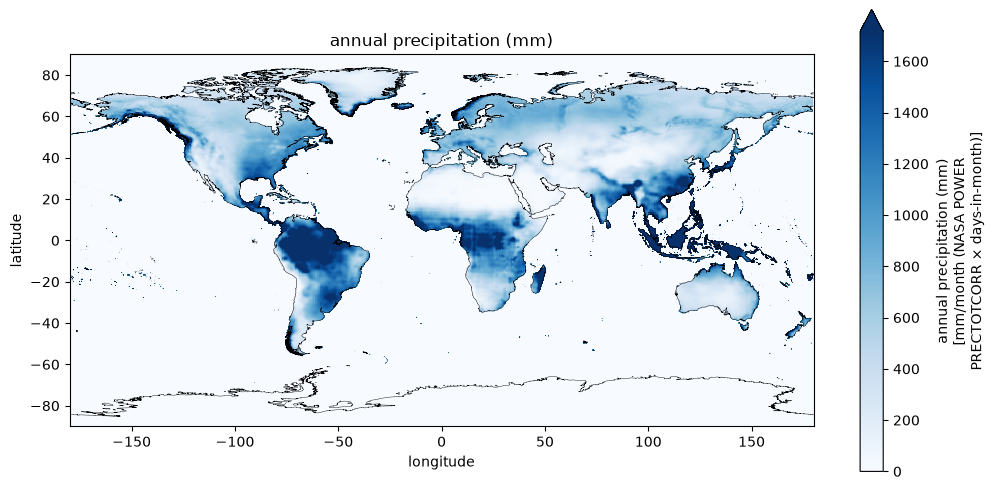

In [5]:
annual_total = precip_monthly.sum('month')
annual_total.name = 'annual precipitation (mm)'
plot_map(annual_total, cmap='Blues', robust=True)

<Axes: title={'center': 'wettest − driest month (mm)'}, xlabel='longitude', ylabel='latitude'>

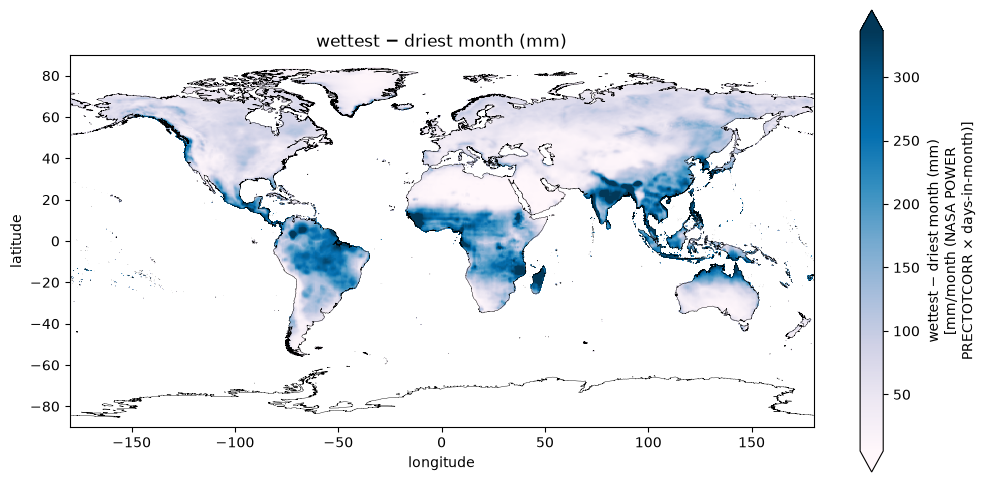

In [6]:
monthly_range = precip_monthly.max('month') - precip_monthly.min('month')
monthly_range.name = 'wettest − driest month (mm)'
plot_map(monthly_range, cmap='PuBu', robust=True)

## 5. Preference knobs → balance

Per-month triangular comfort function, then annual mean:

```
comfort(month) = clip(1 − |precip(month) − ideal_monthly_mm| / tolerance_mm, 0, 1)
balance        = mean of comfort over 12 months
```

Range 0–1, higher = better. Because balance is applied per month before averaging, a place with a steady 80 mm every month scores 1.0 while a monsoon region that averages 80 mm/month but swings from 5 mm to 400 mm scores near 0 — the whole reason we didn't just use annual total.

**Defaults:** `IDEAL_MONTHLY_MM = 80` (≈ 960 mm/year, comfortably temperate) and `TOLERANCE_MM = 60`, so anything under ~20 mm/month (drought) or over ~140 mm/month (deluge) starts scoring below 1.

**Tuning notes** (all instant to change, no re-fetch):

- *Prefers dry & sunny (Mediterranean, desert-adjacent):* drop `IDEAL_MONTHLY_MM` to ~30 and set `TOLERANCE_MM` to ~30.
- *Prefers lush and always-green (rainforest lover):* raise `IDEAL_MONTHLY_MM` to ~200 and widen `TOLERANCE_MM` to ~150.
- *Very picky (steady temperate rain):* `IDEAL_MONTHLY_MM=80`, `TOLERANCE_MM=30`.
* *Dislike all rain:* `IDEAL_MONTHLY_MM=0`, `TOLERANCE_MM=100`.

In [7]:
IDEAL_MONTHLY_MM = 80.0  # mm — target monthly precipitation total
TOLERANCE_MM = 60.0      # mm — half-width of the comfort band

balance = compute_precipitation_balance(
    source=intermediate,
    ideal_monthly_mm=IDEAL_MONTHLY_MM,
    tolerance_mm=TOLERANCE_MM,
)
balance.name = VARIABLE
balance.attrs['ideal_monthly_mm'] = IDEAL_MONTHLY_MM
balance.attrs['tolerance_mm'] = TOLERANCE_MM
balance

<xarray.DataArray 'precipitation_balance' (lat: 360, lon: 720)> Size: 1MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(360, 720), dtype=float32)
Coordinates:
  * lat      (lat) float64 3kB -89.75 -89.25 -88.75 -88.25 ... 88.75 89.25 89.75
  * lon      (lon) float64 6kB -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8
Attributes:
    units:             mm/month (NASA POWER PRECTOTCORR × days-in-month)
    ideal_monthly_mm:  80.0
    tolerance_mm:      60.0

## 6. Plot balance (and a preference-sensitivity peek)

<Axes: title={'center': 'precipitation_balance (ideal=80.0 mm/mo, tolerance=60.0 mm)'}, xlabel='longitude', ylabel='latitude'>

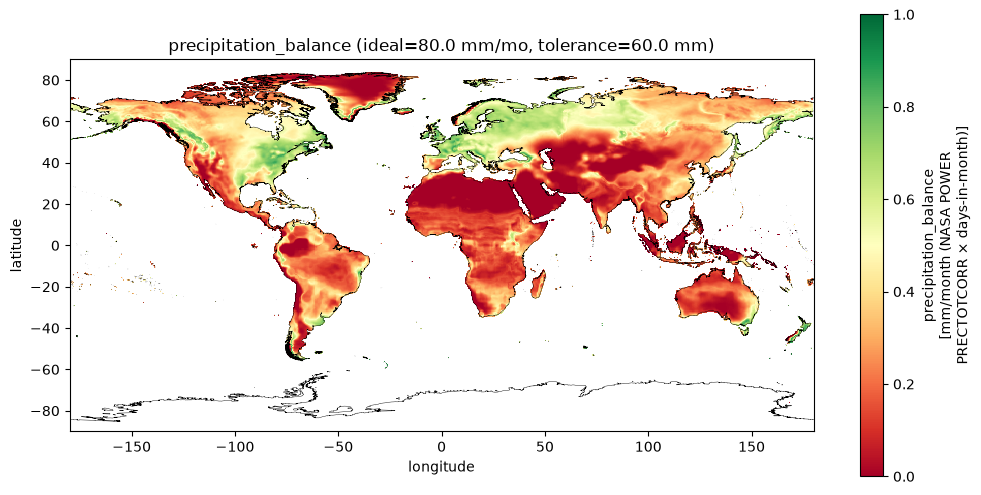

In [8]:
plot_map(balance, cmap='RdYlGn', vmin=0, vmax=1,
         title=f'precipitation_balance (ideal={IDEAL_MONTHLY_MM} mm/mo, tolerance={TOLERANCE_MM} mm)')

<Axes: title={'center': 'precipitation_balance (dry lover: ideal=30 mm/mo, tolerance=30 mm)'}, xlabel='longitude', ylabel='latitude'>

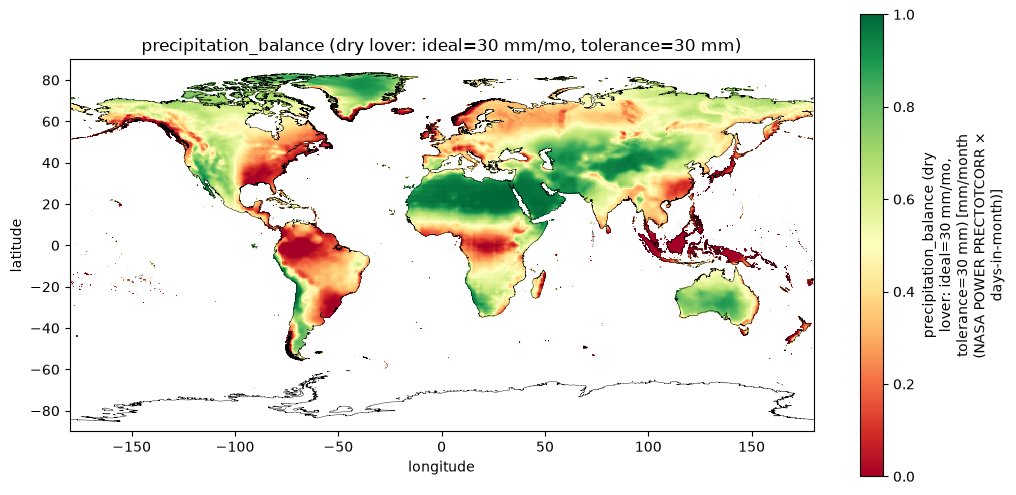

In [9]:
# Same intermediate, different preferences — proves the knobs are cheap.
alt = compute_precipitation_balance(source=intermediate, ideal_monthly_mm=0.0, tolerance_mm=100.0)
alt.name = 'precipitation_balance (dry lover: ideal=30 mm/mo, tolerance=30 mm)'
plot_map(alt, cmap='RdYlGn', vmin=0, vmax=1)

## 7. Save

Writes the default-preference score to `processed/precipitation_balance.nc` so `90_scoring.ipynb` picks it up. Re-scoring the atlas for a different preference is a one-liner: `compute_precipitation_balance(...).to_netcdf(...)`.

In [10]:
out = save_variable(balance, VARIABLE)
print(f'wrote {out}')

wrote /Users/lutz/Documents/alfatraining/projects/data-science-notebooks/data/world-livable-atlas/processed/precipitation_balance.nc
